In [36]:
# =========================================
# Dengue Fever Analysis using Machine Learning
# =========================================

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import pandas as pd

# Load dataset
df = pd.read_csv("dengue_data.csv")

# Show first 5 rows
df.head()

,Month,Year,Region,Dengue_Cases,Dengue_Deaths
0,January,2016,Punjab,320,1
1,February,2016,Punjab,280,0
2,March,2016,Punjab,195,0
3,April,2016,Punjab,150,0
4,May,2016,Punjab,180,1


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Month          420 non-null    str  
 1   Year           420 non-null    int64
 2   Region         420 non-null    str  
 3   Dengue_Cases   420 non-null    int64
 4   Dengue_Deaths  420 non-null    int64
dtypes: int64(3), str(2)
memory usage: 16.5 KB


In [6]:
df.describe()

,Year,Dengue_Cases,Dengue_Deaths
count,420.0000,420.000000,420.000000
mean,2018.0000,421.750000,2.773810
std,1.4159,992.468102,4.605567
min,2016.0000,15.000000,0.000000
25%,2017.0000,80.000000,0.000000
50%,2018.0000,180.000000,1.000000
75%,2019.0000,350.000000,3.250000
max,2020.0000,12450.000000,48.000000


In [7]:
df.describe()

,Year,Dengue_Cases,Dengue_Deaths
count,420.0000,420.000000,420.000000
mean,2018.0000,421.750000,2.773810
std,1.4159,992.468102,4.605567
min,2016.0000,15.000000,0.000000
25%,2017.0000,80.000000,0.000000
50%,2018.0000,180.000000,1.000000
75%,2019.0000,350.000000,3.250000
max,2020.0000,12450.000000,48.000000


In [8]:
df.describe()

,Year,Dengue_Cases,Dengue_Deaths
count,420.0000,420.000000,420.000000
mean,2018.0000,421.750000,2.773810
std,1.4159,992.468102,4.605567
min,2016.0000,15.000000,0.000000
25%,2017.0000,80.000000,0.000000
50%,2018.0000,180.000000,1.000000
75%,2019.0000,350.000000,3.250000
max,2020.0000,12450.000000,48.000000


In [9]:
df.isnull().sum()

Month            0
Year             0
Region           0
Dengue_Cases     0
Dengue_Deaths    0
dtype: int64

In [10]:
df.columns

Index(['Month', 'Year', 'Region', 'Dengue_Cases', 'Dengue_Deaths'], dtype='str')

In [11]:
df.columns

Index(['Month', 'Year', 'Region', 'Dengue_Cases', 'Dengue_Deaths'], dtype='str')

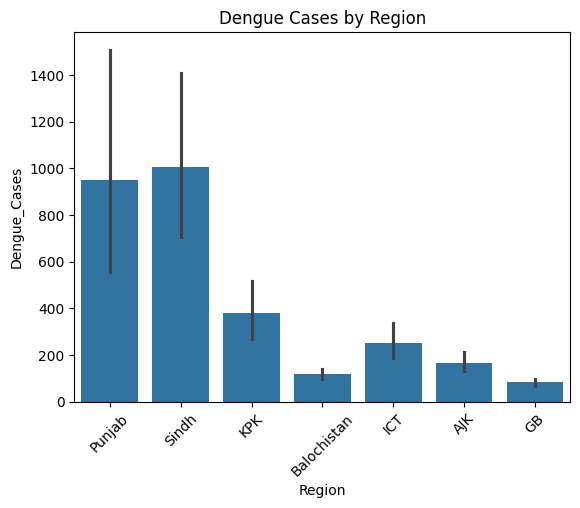

In [12]:
#visualization
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x="Region", y="Dengue_Cases", data=df)

plt.title("Dengue Cases by Region")
plt.xticks(rotation=45)

plt.show()

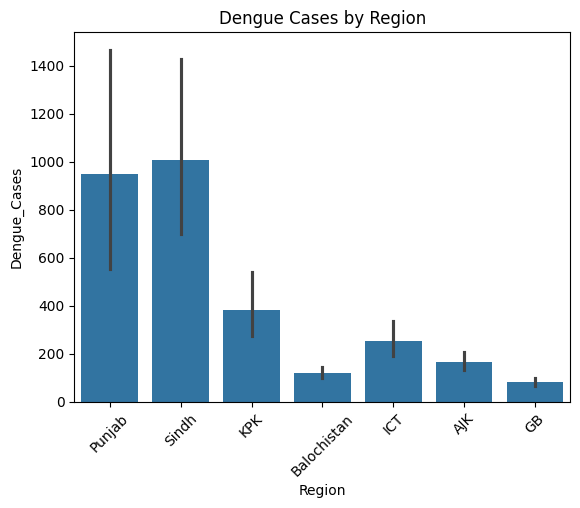

In [15]:
sns.barplot(x="Region", y="Dengue_Cases", data=df)

plt.title("Dengue Cases by Region")
plt.xticks(rotation=45)

plt.show()

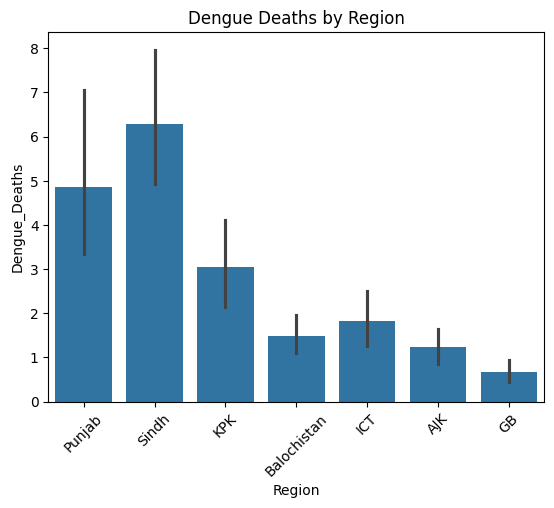

In [16]:
sns.barplot(x="Region", y="Dengue_Deaths", data=df)

plt.title("Dengue Deaths by Region")
plt.xticks(rotation=45)

plt.show()

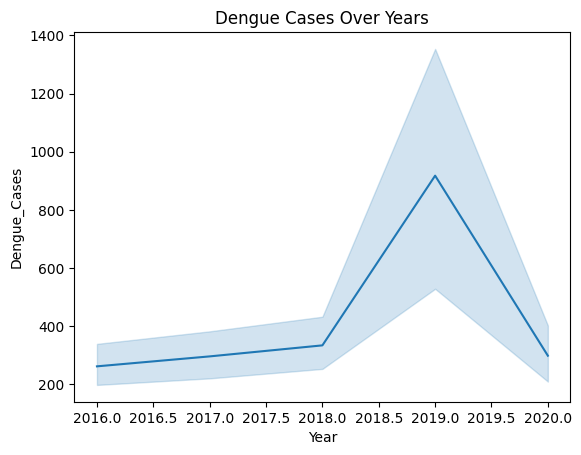

In [17]:
sns.lineplot(x="Year", y="Dengue_Cases", data=df)

plt.title("Dengue Cases Over Years")

plt.show()

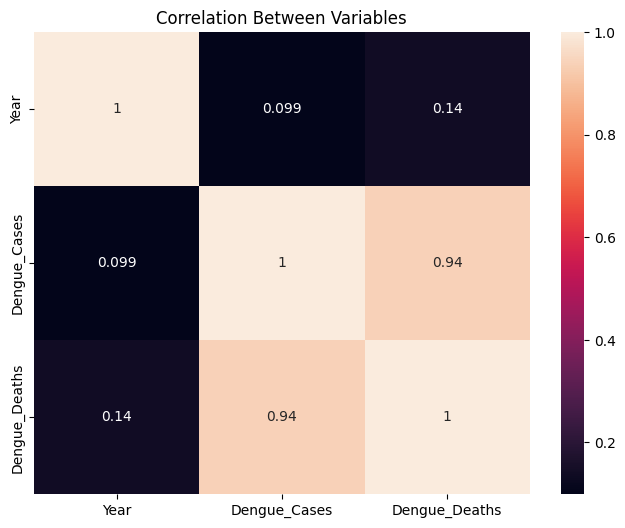

In [18]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True), annot=True)

plt.title("Correlation Between Variables")

plt.show()

In [19]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Region"] = le.fit_transform(df["Region"])

In [20]:
X = df.drop("Dengue_Cases", axis=1)
y = df["Dengue_Cases"]

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
df["Region"] = le.fit_transform(df["Region"])

In [28]:
X = df.drop("Dengue_Cases", axis=1)
y = df["Dengue_Cases"]

In [29]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Month"] = le.fit_transform(df["Month"])
df["Region"] = le.fit_transform(df["Region"])

In [30]:
X = df.drop("Dengue_Cases", axis=1)
y = df["Dengue_Cases"]

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [32]:
#Linera Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model = LinearRegression()

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Mean Squared Error:", mean_squared_error(y_test, pred))

Mean Squared Error: 109452.07948209892


In [33]:
#Decision Treee Regression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

model2 = DecisionTreeRegressor()

model2.fit(X_train, y_train)

pred2 = model2.predict(X_test)

print("Decision Tree Error:", mean_squared_error(y_test, pred2))

Decision Tree Error: 283166.96428571426


In [34]:
#Random Forest Regression
from sklearn.ensemble import RandomForestRegressor

model3 = RandomForestRegressor()

model3.fit(X_train, y_train)

pred3 = model3.predict(X_test)

print("Random Forest Error:", mean_squared_error(y_test, pred3))

Random Forest Error: 34744.78726190476


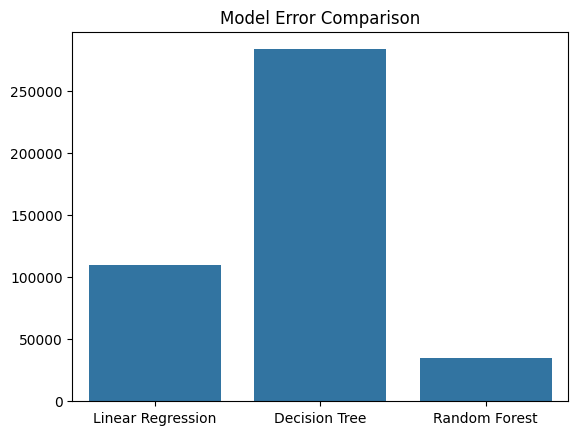

In [35]:
#Model comparison graph
models = ["Linear Regression", "Decision Tree", "Random Forest"]

errors = [
mean_squared_error(y_test, pred),
mean_squared_error(y_test, pred2),
mean_squared_error(y_test, pred3)
]

import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x=models, y=errors)

plt.title("Model Error Comparison")

plt.show()